# Setup

In [23]:
%reload_ext autoreload
%autoreload 2

In [3]:
import pymonntorch
pymonntorch.__version__

'0.1.4'

In [24]:
import torch
from pymonntorch import *
from conex import *

import json

from matplotlib import pyplot as plt
import numpy as np

from Sequence import Sequence
from Simulation import Simulation

# Params

In [28]:
from params_6_SNN import params_base, params_c0, params_c1, params_c2, params_c3

# Scenario Matrix

In [6]:
params = np.linspace(0.01, 0.049, 40)
params

array([0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018,
       0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027,
       0.028, 0.029, 0.03 , 0.031, 0.032, 0.033, 0.034, 0.035, 0.036,
       0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044, 0.045,
       0.046, 0.047, 0.048, 0.049])

In [20]:
param_result = np.ones((40, 40))
params = np.linspace(0.01, 0.049, 40)

u = 0
for i in params : 
    v = 0
    for j in params : 
        params_base["COOP12"] = i
        params_base["COOP21"] = j

        sim = Simulation(params_base)
        param_result[u][v] = sim.run()[0]
        v += 1
    u += 1


param_result_json = param_result.tolist()
json_file_path = 'new_data.json'
with open(json_file_path, 'w') as json_file:
    json.dump(param_result_json, json_file)

print("parameter results have been saved successfully")

Network['Network_1', 'Network'](Neurons: tensor(75000)|180 groups, Synapses: tensor(201937500)|1093 groups){1:TimeResolution(dt=1,)}
NeuronGroup['exi', 'NeuronGroup', 'ng'](1000){220:SimpleDendriteStructure(Proximal_max_delay=1,Distal_max_delay=1,Apical_max_delay=None,proximal_min_delay=0,distal_min_delay=0,apical_min_delay=None,)240:SimpleDendriteComputation(I_tau=None,apical_provocativeness=None,distal_provocativeness=None,)250:InitialActivation()259:BackgroundActivityCurrentBased()260:LIF(R=0.55,tau=7,threshold=-45,v_reset=-70,v_rest=-65,init_v=tensor([-69.6830, -85.9126, -76.6595, -58.7979, -66.1434, -51.0157, -73.5120,
        -59.5039, -58.0548, -64.6264, -56.7031, -58.0220, -89.2194, -91.6829,
        -94.0304, -57.3805, -52.3458, -98.3635, -93.6648, -85.1987, -91.7621,
        -70.9305, -74.9352, -95.6314, -73.0648, -98.2521, -60.7615, -62.3731,
        -92.9240, -78.0799, -58.6683, -50.3405, -71.7330, -85.3809, -72.3211,
        -70.7978, -94.2903, -73.2742, -80.4782, -82.3016

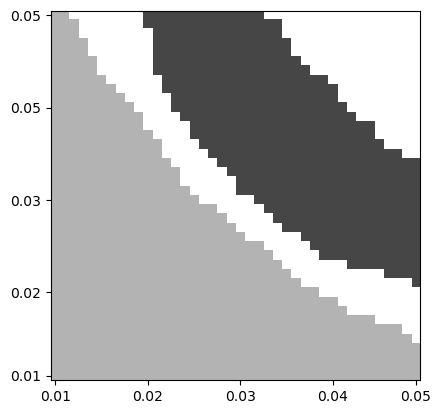

In [95]:
json_file_path = 'param_result.json'

with open(json_file_path, 'r') as json_file:
    param_result = json.load(json_file)


param_result = np.array(param_result)

param_result[param_result == 1] = 70
param_result[param_result == 2] = 180
param_result[param_result == 0] = 255

plt.imshow(param_result, cmap = "gray", vmin = 0, vmax = 255)
plt.xticks([])  
 
plt.xticks([0,10, 20,30, 39], labels = ["0.01", "0.02", "0.03", "0.04","0.05"])
plt.yticks([0,10, 20,30, 39], labels = ["0.05", "0.05", "0.03", "0.02", "0.01"])

plt.savefig('./scenario_matrix.svg')
plt.show()

# Activities of examples

In [26]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

In [7]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(10) : 
    sim = Simulation(params = params_c3)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C3 : Executed on 10 simulations successfully")

C3 : Executed on 10 simulations successfully


### c3

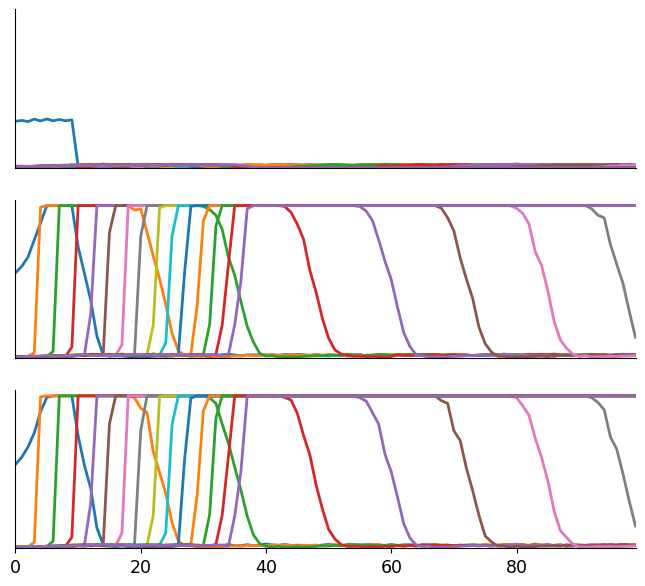

In [89]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])
plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c3.svg')
plt.show()

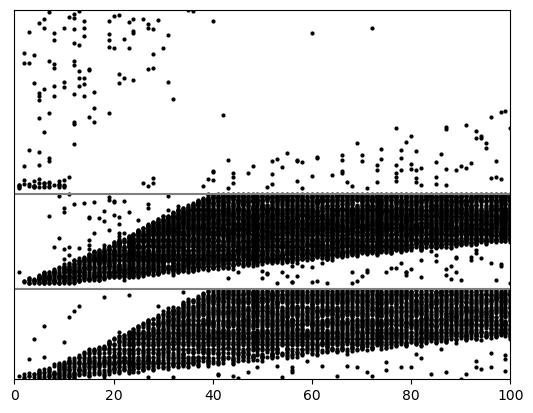

In [90]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c3.svg')
plt.show()

### c2

In [29]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(10) : 
    sim = Simulation(params = params_c2)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C2 : Executed on 10 simulations successfully")

Network['Network_1', 'Network'](Neurons: tensor(75000)|180 groups, Synapses: tensor(201937500)|1093 groups){1:TimeResolution(dt=1,)}
NeuronGroup['exi', 'NeuronGroup', 'ng'](1000){220:SimpleDendriteStructure(Proximal_max_delay=1,Distal_max_delay=1,Apical_max_delay=None,proximal_min_delay=0,distal_min_delay=0,apical_min_delay=None,)240:SimpleDendriteComputation(I_tau=None,apical_provocativeness=None,distal_provocativeness=None,)250:InitialActivation()259:BackgroundActivityCurrentBased()260:LIF(R=0.55,tau=7,threshold=-45,v_reset=-70,v_rest=-65,init_v=tensor([-56.2415, -95.0840, -76.4972, -69.7791, -72.3123, -64.2655, -53.8910,
        -88.7531, -87.3423, -71.7248, -81.3141, -96.8913, -84.6368, -76.9653,
        -97.3410, -65.2176, -82.1323, -66.4354, -63.7931, -52.5654, -98.0380,
        -82.8662, -89.8645, -82.7889, -53.6853, -96.8729, -59.4419, -96.7644,
        -77.8140, -90.0814, -88.4813, -50.0827, -72.5858, -52.1465, -52.3630,
        -96.6555, -68.6925, -64.3415, -95.6317, -50.7393

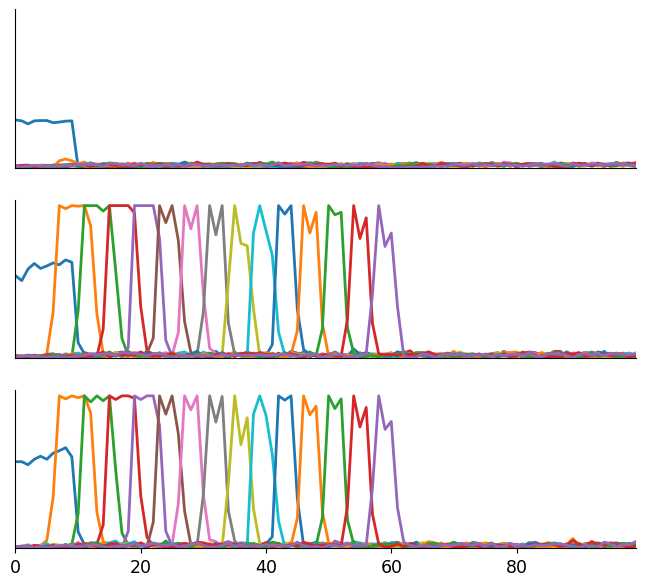

In [31]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])
plt.ylim(0, 0.52)

plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
# plt.savefig('./act_c2.svg')
plt.show()

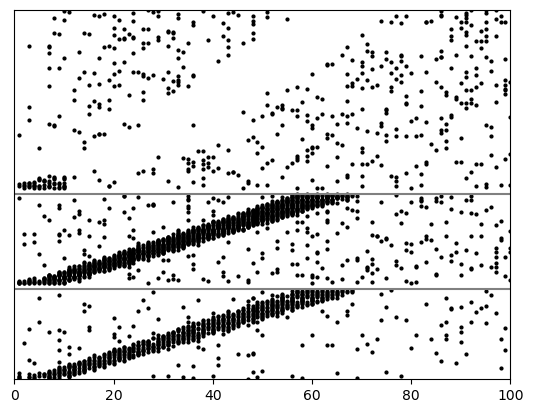

In [17]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c2.svg')
plt.show()

### c1

In [9]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(10) : 
    sim = Simulation(params = params_c1)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C1 : Executed on 10 simulations successfully")

C1 : Executed on 10 simulations successfully


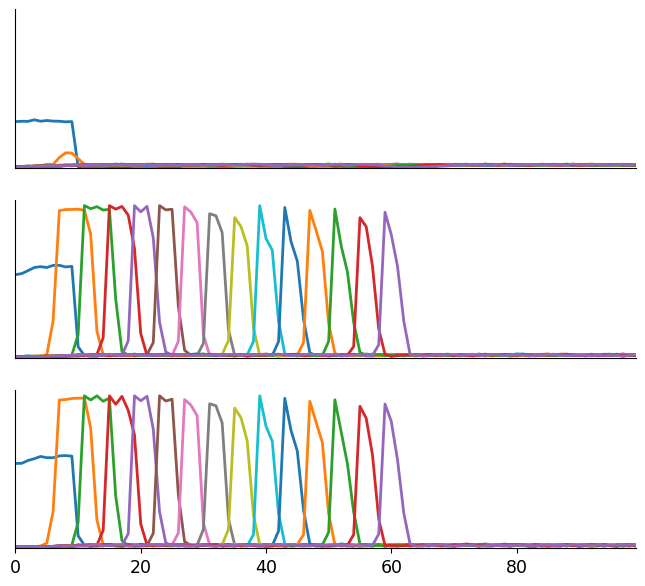

In [23]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])

plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])

plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c1.svg')
plt.show()

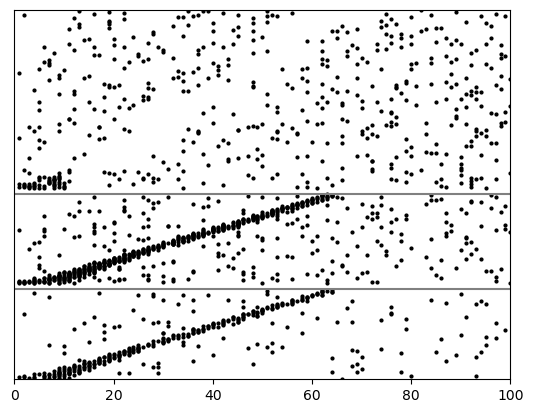

In [24]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c1.svg')
plt.show()

### c0

In [10]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(10) : 
    sim = Simulation(params = params_c0)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C0 : Executed on 10 simulations successfully")

C0 : Executed on 10 simulations successfully


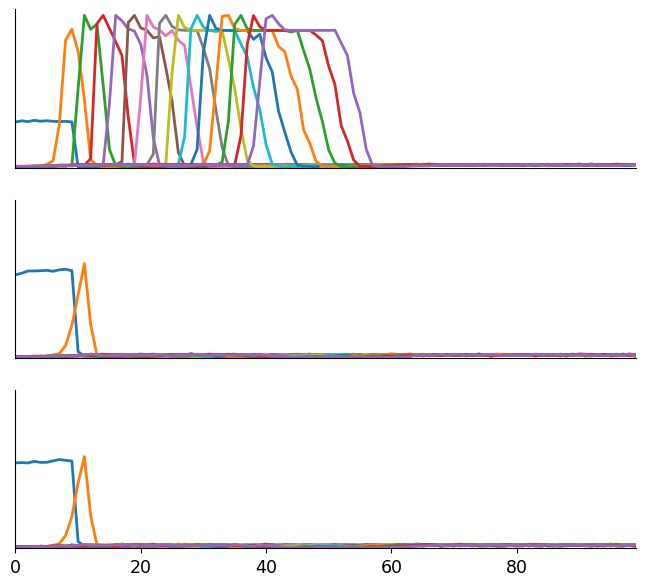

In [26]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])

plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c0.svg')
plt.show()

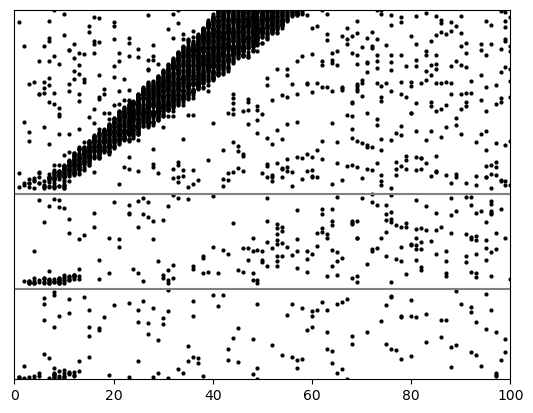

In [27]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c0.svg')